# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import LabelEncoder
from implicit.als import AlternatingLeastSquares
import matplotlib.pyplot as plt
import seaborn as sns

/home/mle-user/mle_projects/mle-music-recsys/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
tracks = pd.read_parquet("tracks.parquet")
tracks.head()

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


In [3]:
catalog_names = pd.read_parquet('catalog_names.parquet')
catalog_names.head()

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


In [4]:
interactions = pd.read_parquet('interactions.parquet')
interactions.head()

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [5]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [16]:
print(tracks['albums'].isna().sum())
print(tracks['artists'].isna().sum())
print(tracks['genres'].isna().sum())

0
0
0


In [22]:
print(f"Количество треков без альбомов: {(tracks['albums'].str.len() == 0).sum()}")
print(f"Количество треков без артистов: {(tracks['artists'].str.len() == 0).sum()}")
print(f"Количество треков без жанров: {(tracks['genres'].str.len() == 0).sum()}")

Количество треков без альбомов: 18
Количество треков без артистов: 15369
Количество треков без жанров: 3687


Отфильтруем треки, у которых нет жанров, потому что в построенной матрице они все равно будут иметь пустые строки

In [5]:
tracks = tracks[tracks['genres'].str.len() > 0]

In [20]:
tracks['track_id'] = tracks['track_id'].astype('int32')

In [6]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


In [9]:
catalog_names['type'].unique()

array(['album', 'artist', 'genre', 'track'], dtype=object)

In [15]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


In [26]:
interactions['track_seq'].isna().any()

False

In [24]:
def optimize_numeric_types(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.select_dtypes(include=['int', 'float']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer' if 'int' in str(df[col].dtype) else 'float')

    return df

In [27]:
tracks = optimize_numeric_types(tracks)
interactions = optimize_numeric_types(interactions)

In [26]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 996313 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   track_id  996313 non-null  int32 
 1   albums    996313 non-null  object
 2   artists   996313 non-null  object
 3   genres    996313 non-null  object
dtypes: int32(1), object(3)
memory usage: 34.2+ MB


In [28]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

В исходном наборе данных имеются пропуски среди альбомов, артистов и жанров. Было принято решение отбросить все треки, у которых не заполено поле с жанрами, поскольку именно этот признак будет использоваться для построения матрицы взаимодействий. Остальные признаки не должны сильно повлиять на качество рекомендаций

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

<Axes: xlabel='track_id', ylabel='Count'>

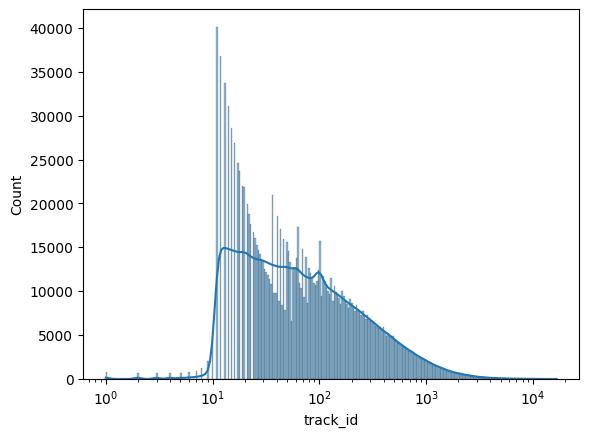

In [7]:
listened_cnt = interactions.groupby('user_id')['track_id'].count().reset_index()

sns.histplot(
    listened_cnt['track_id'], 
    log_scale=True,
    kde=True)

Наиболее популярные треки

In [8]:
track_listenings = interactions['track_id'].value_counts().reset_index()
track_listenings.columns= ['track_id', 'listenings']
most_popular = track_listenings.sort_values(by='listenings', ascending=False).head(10)
most_popular = most_popular.merge(catalog_names[catalog_names['type'] == 'track'][['id', 'name']], left_on='track_id', right_on='id', how='left').drop(columns=['id'])

most_popular

,track_id,listenings,name
0,53404,111062,Smells Like Teen Spirit
1,33311009,106921,Believer
2,178529,101924,Numb
3,35505245,99490,I Got Love
4,65851540,86670,Юность
5,24692821,86246,Way Down We Go
6,32947997,85886,Shape of You
7,51241318,85244,In The End
8,795836,85042,Shape Of My Heart
9,45499814,84748,Life


Наиболее популярные жанры

In [13]:
most_popular_genres = track_listenings.merge(tracks[['track_id', 'genres']], on='track_id', how='left')\
    .explode(column=['genres'], ignore_index=True)\
    .groupby('genres')['listenings'].sum().reset_index()\
    .sort_values(by='listenings', ascending=False)\
    .merge(catalog_names[catalog_names['type'] == 'genre'][['id', 'name']], left_on='genres', right_on='id', how='left')\
    .drop(columns=['genres']).head(10)

most_popular_genres

,listenings,id,name
0,55578312,11.0,pop
1,37799821,75.0,rap
2,31092013,102.0,allrock
3,26626241,20.0,ruspop
4,25303695,3.0,rusrap
5,20120981,68.0,electronics
6,16291557,16.0,dance
7,13166147,2.0,rusrock
8,12772644,14.0,rock
9,12437375,47.0,metal


Треки, которые никто не прослушал

In [16]:
track_listenings.query("listenings == 0")

,track_id,listenings


In [15]:
track_listenings.sort_values(by='listenings', ascending=False).tail()

,track_id,listenings
999847,592600,5
999848,61201731,5
999849,52080116,5
999850,73942221,5
999851,692654,5


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [29]:
items = tracks.copy()
events = interactions.copy()

In [30]:
items = items.rename(columns={'track_id': 'item_id'})
events = events.rename(columns={'track_id': 'item_id'})

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [31]:
items.to_parquet("items.parquet")
events.to_parquet("events.parquet")

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [32]:
import gc

del tracks
del interactions
del track_listenings
del most_popular
del most_popular_genres

gc.collect()

0

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.